# TabNet — Predicción de Sepsis desde el Vector Tabular

TabNet aprende a seleccionar features relevantes por instancia mediante atención secuencial,
produciendo predicciones interpretables sin preprocesamiento manual.

**Input**: el mismo vector de 99 características que XGBoost — estadísticas de ventana
(last/mean/trend/range) sobre los 7 signos vitales principales **y** los 15 laboratorios,
más edad, sexo y los componentes de qSOFA y SIRS. No es un modelo solo-laboratorio.
**Diferencia clave**: TabNet aprende la selección de features end-to-end; XGBoost usa árboles.
**Rol en el sistema**: línea de base tabular independiente. Su encoder **no** alimenta la red de
fusión (la modalidad tabular se incorpora a la fusión mediante proyección directa del vector).
**Salida**: modelos para 6h y 12h + máscaras de atención para interpretabilidad.

In [1]:
import polars as pl
import numpy as np
import json
from pathlib import Path
import time

import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

MIMIC   = Path.home() / "mimic-iv-3.0"
HOSP    = MIMIC / "hosp"
PROC    = Path("../data/processed")
OUT_DIR = Path("../experiments/tabnet")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED   = 42

# Compat torch>=2.6: ReduceLROnPlateau renombro is_better -> _is_better.
# pytorch-tabnet decide pasar la metrica con hasattr(scheduler_fn,'is_better');
# restauramos el alias para que el scheduler siga recibiendo la metrica (val AUC).
if not hasattr(torch.optim.lr_scheduler.ReduceLROnPlateau, 'is_better'):
    torch.optim.lr_scheduler.ReduceLROnPlateau.is_better = (
        torch.optim.lr_scheduler.ReduceLROnPlateau._is_better
    )
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}")

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.11.0+cu128


## PASO 1 — Cargar datos (igual que XGBoost)

In [2]:
log("Cargando datos ...")

cohort = pl.read_parquet(PROC / "cohort.parquet").select([
    "subject_id", "stay_id", "los_hours", "sepsis",
])
splits = pl.read_parquet(PROC / "splits.parquet").select(["stay_id", "split"])
cohort = cohort.join(splits, on="stay_id", how="left")

vitals_meta = (
    pl.read_parquet(PROC / "vitals/vitals_hourly.parquet",
                    columns=["stay_id", "onset_hour"])
    .unique(subset=["stay_id"])
)
cohort = cohort.join(vitals_meta, on="stay_id", how="left")

patients = pl.read_csv(
    HOSP / "patients.csv.gz", columns=["subject_id", "gender", "anchor_age"]
).with_columns((pl.col("gender") == "M").cast(pl.Int8).alias("male"))
cohort = cohort.join(patients.select(["subject_id", "anchor_age", "male"]),
                     on="subject_id", how="left")

VITAL_COLS = ["heart_rate", "resp_rate", "spo2", "map", "temp_c", "fio2", "gcs_total"]
LAB_COLS   = ["platelet", "bilirubin", "creatinine", "lactate", "wbc",
              "hemoglobin", "sodium", "potassium", "glucose",
              "bicarbonate", "bun", "albumin", "inr", "ph", "pao2"]

vitals = pl.read_parquet(PROC / "vitals/vitals_hourly.parquet",
                         columns=["stay_id", "hours_from_intime"] + VITAL_COLS)
labs   = pl.read_parquet(PROC / "labs/labs_hourly.parquet",
                         columns=["stay_id", "hours_from_intime"] + LAB_COLS)

log(f"Cohorte: {len(cohort):,}  |  Vitales: {vitals.shape}  |  Labs: {labs.shape}")

[19:43:58] Cargando datos ...


[19:43:58] Cohorte: 74,829  |  Vitales: (7940236, 9)  |  Labs: (7940236, 17)


## PASO 2 — Tiempo de referencia y features (reutilizado de XGBoost)

In [3]:
def assign_ref_hour(cohort, horizon, seed):
    rng = np.random.default_rng(seed)
    out = []
    for r in cohort.to_dicts():
        if r["sepsis"] == 1:
            ref = (int(r["onset_hour"]) - horizon) if r["onset_hour"] is not None else None
        else:
            lo, hi = 24, int(r["los_hours"]) - horizon
            ref = int(rng.integers(lo, hi + 1)) if hi >= lo else None
        if ref is not None and ref >= 12:
            r["ref_hour"] = ref
            out.append(r)
    return pl.DataFrame(out)


def window_stats(data, ref, value_cols):
    windowed = (
        data.join(ref.select(["stay_id", "ref_hour"]), on="stay_id", how="inner")
        .filter(
            (pl.col("hours_from_intime") <= pl.col("ref_hour")) &
            (pl.col("hours_from_intime") >= pl.col("ref_hour") - 24)
        )
        .sort("hours_from_intime")
    )
    agg = []
    for c in value_cols:
        if c not in windowed.columns:
            continue
        agg += [
            pl.col(c).last().alias(f"{c}_last"),
            pl.col(c).mean().alias(f"{c}_mean"),
            (pl.col(c).last() - pl.col(c).first()).alias(f"{c}_trend"),
            (pl.col(c).max()  - pl.col(c).min()).alias(f"{c}_range"),
        ]
    return windowed.group_by("stay_id").agg(agg)


def extract_features(cohort_h):
    vf = window_stats(vitals, cohort_h, VITAL_COLS)
    lf = window_stats(labs,   cohort_h, LAB_COLS)

    qsofa = (
        vf.select(["stay_id", "resp_rate_last", "map_last", "gcs_total_last"])
        .with_columns([
            (pl.col("resp_rate_last") >= 22).cast(pl.Int8).fill_null(0).alias("qsofa_rr"),
            (pl.col("map_last")       <= 70).cast(pl.Int8).fill_null(0).alias("qsofa_map"),
            (pl.col("gcs_total_last") <  15).cast(pl.Int8).fill_null(0).alias("qsofa_gcs"),
        ])
        .with_columns(
            (pl.col("qsofa_rr") + pl.col("qsofa_map") + pl.col("qsofa_gcs")).alias("qsofa")
        )
        .select(["stay_id", "qsofa", "qsofa_rr", "qsofa_map", "qsofa_gcs"])
    )
    sirs = (
        vf.select(["stay_id", "temp_c_last", "heart_rate_last", "resp_rate_last"])
        .join(lf.select(["stay_id", "wbc_last"]), on="stay_id", how="left")
        .with_columns([
            ((pl.col("temp_c_last") > 38) | (pl.col("temp_c_last") < 36))
            .cast(pl.Int8).fill_null(0).alias("sirs_temp"),
            (pl.col("heart_rate_last") > 90).cast(pl.Int8).fill_null(0).alias("sirs_hr"),
            (pl.col("resp_rate_last")  > 20).cast(pl.Int8).fill_null(0).alias("sirs_rr"),
            ((pl.col("wbc_last") > 12) | (pl.col("wbc_last") < 4))
            .cast(pl.Int8).fill_null(0).alias("sirs_wbc"),
        ])
        .with_columns(
            (pl.col("sirs_temp") + pl.col("sirs_hr") + pl.col("sirs_rr") + pl.col("sirs_wbc"))
            .alias("sirs")
        )
        .select(["stay_id", "sirs", "sirs_temp", "sirs_hr", "sirs_rr", "sirs_wbc"])
    )
    return (
        cohort_h.select(["stay_id", "subject_id", "split", "sepsis",
                         "ref_hour", "anchor_age", "male"])
        .join(vf, on="stay_id", how="left")
        .join(lf, on="stay_id", how="left")
        .join(qsofa, on="stay_id", how="left")
        .join(sirs,  on="stay_id", how="left")
    )


cohort_6h  = assign_ref_hour(cohort, 6,  SEED)
cohort_12h = assign_ref_hour(cohort, 12, SEED + 1)

log("Extrayendo features 6h ...")
feats_6h  = extract_features(cohort_6h)
log("Extrayendo features 12h ...")
feats_12h = extract_features(cohort_12h)

META_COLS    = ["stay_id", "subject_id", "split", "sepsis", "ref_hour"]
FEATURE_COLS = [c for c in feats_6h.columns if c not in META_COLS]
print(f"Features: {len(FEATURE_COLS)}")

[19:43:58] Extrayendo features 6h ...


[19:43:59] Extrayendo features 12h ...


Features: 99


## PASO 3 — Preparar arrays: imputación y normalización

TabNet acepta NaN nativamente pero normalizar mejora la convergencia.  
Usamos mediana para imputar (robusta a outliers clínicos) y StandardScaler.

In [4]:
def get_Xy(feats, split_name):
    df = feats.filter(pl.col("split") == split_name)
    X  = df.select(FEATURE_COLS).to_pandas().astype(float).values
    y  = df["sepsis"].to_numpy().astype(int)
    return X, y

def prepare_splits(feats):
    X_tr, y_tr = get_Xy(feats, "train")
    X_va, y_va = get_Xy(feats, "val")
    X_te, y_te = get_Xy(feats, "test")

    # Imputación mediana (fit solo en train)
    imp = SimpleImputer(strategy="median")
    X_tr = imp.fit_transform(X_tr)
    X_va = imp.transform(X_va)
    X_te = imp.transform(X_te)

    # Normalización (fit solo en train)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_va = scaler.transform(X_va)
    X_te = scaler.transform(X_te)

    return (X_tr, y_tr), (X_va, y_va), (X_te, y_te), imp, scaler

(X_tr6,  y_tr6),  (X_va6,  y_va6),  (X_te6,  y_te6),  imp6,  sc6  = prepare_splits(feats_6h)
(X_tr12, y_tr12), (X_va12, y_va12), (X_te12, y_te12), imp12, sc12 = prepare_splits(feats_12h)

spw6  = (y_tr6  == 0).sum() / max((y_tr6  == 1).sum(), 1)
spw12 = (y_tr12 == 0).sum() / max((y_tr12 == 1).sum(), 1)

print(f"Train 6h:  {X_tr6.shape}  pos_weight={spw6:.2f}")
print(f"Train 12h: {X_tr12.shape}  pos_weight={spw12:.2f}")

Train 6h:  (37376, 99)  pos_weight=11.27
Train 12h: (32992, 99)  pos_weight=11.09


## PASO 4 — Entrenar TabNet

In [5]:
TABNET_PARAMS = dict(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.3,
    n_independent=2,
    n_shared=2,
    lambda_sparse=1e-3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3, weight_decay=1e-5),
    scheduler_fn=torch.optim.lr_scheduler.ReduceLROnPlateau,
    scheduler_params=dict(mode="max", patience=5, factor=0.5),
    mask_type="sparsemax",
    device_name=DEVICE,
    seed=SEED,
    verbose=10,
)

def train_tabnet(X_tr, y_tr, X_va, y_va, pos_weight, params):
    weights = np.where(y_tr == 1, pos_weight, 1.0)
    model = TabNetClassifier(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_name=["val"],
        eval_metric=["auc"],
        max_epochs=200,
        patience=20,
        batch_size=2048,
        virtual_batch_size=256,
        weights=weights,
        drop_last=False,
    )
    return model

log("Entrenando TabNet — horizonte 6h ...")
model_6h  = train_tabnet(X_tr6,  y_tr6,  X_va6,  y_va6,  spw6,  TABNET_PARAMS)

log("Entrenando TabNet — horizonte 12h ...")
model_12h = train_tabnet(X_tr12, y_tr12, X_va12, y_va12, spw12, TABNET_PARAMS)

[19:44:00] Entrenando TabNet — horizonte 6h ...


/home/fer/miniconda3/envs/sepsis-tfm/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.58552 | val_auc: 0.5204  |  0:00:01s


epoch 10 | loss: 0.68945 | val_auc: 0.60268 |  0:00:08s


epoch 20 | loss: 0.63482 | val_auc: 0.66436 |  0:00:15s


...

epoch 90 | loss: 0.581   | val_auc: 0.70378 |  0:01:03s


epoch 100| loss: 0.57627 | val_auc: 0.69915 |  0:01:10s


epoch 110| loss: 0.57472 | val_auc: 0.70368 |  0:01:18s



Early stopping occurred at epoch 111 with best_epoch = 91 and best_val_auc = 0.70796


/home/fer/miniconda3/envs/sepsis-tfm/lib/python3.10/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


## PASO 5 — Evaluación

In [6]:
def evaluate(model, X, y, label=""):
    probs = model.predict_proba(X)[:, 1]
    auroc = roc_auc_score(y, probs)
    auprc = average_precision_score(y, probs)
    fpr, tpr, _ = roc_curve(y, probs)
    mask = fpr <= 0.10
    sens = float(tpr[mask].max()) if mask.any() else 0.0
    print(f"  {label:<8}  AUROC={auroc:.4f}  AUPRC={auprc:.4f}  Sens@Spec90={sens:.4f}")
    return {"auroc": round(auroc,4), "auprc": round(auprc,4), "sens_at_spec90": round(sens,4)}

print("=" * 60)
print("  HORIZONTE 6h")
print("=" * 60)
r6_val  = evaluate(model_6h, X_va6, y_va6, "Val")
r6_test = evaluate(model_6h, X_te6, y_te6, "Test")

print("\n" + "=" * 60)
print("  HORIZONTE 12h")
print("=" * 60)
r12_val  = evaluate(model_12h, X_va12, y_va12, "Val")
r12_test = evaluate(model_12h, X_te12, y_te12, "Test")

print("\n  XGBoost baseline (referencia):")
print("  6h  test  AUROC=0.8224  AUPRC=0.4657  Sens@Spec90=0.5643")
print("  12h test  AUROC=0.7949  AUPRC=0.4300  Sens@Spec90=0.4904")

  HORIZONTE 6h
  Val       AUROC=0.7125  AUPRC=0.2780  Sens@Spec90=0.3236
  Test      AUROC=0.7655  AUPRC=0.3829  Sens@Spec90=0.4348

  HORIZONTE 12h


  Val       AUROC=0.7080  AUPRC=0.2966  Sens@Spec90=0.3452
  Test      AUROC=0.7695  AUPRC=0.3768  Sens@Spec90=0.4460

  XGBoost baseline (referencia):
  6h  test  AUROC=0.8224  AUPRC=0.4657  Sens@Spec90=0.5643
  12h test  AUROC=0.7949  AUPRC=0.4300  Sens@Spec90=0.4904


## PASO 6 — Máscaras de atención (interpretabilidad TabNet)

TabNet genera máscaras de atención por paso que indican qué features
selecciona para cada muestra. Visualizamos la importancia global (media).

[19:46:49] Calculando máscaras de atención (6h, test set) ...


Top 20 features (atención TabNet media):
   1. gcs_total_mean                   2.2688  ██████████████████████████████
   2. gcs_total_last                   1.8995  █████████████████████████
   3. qsofa                            1.1162  ██████████████
   4. heart_rate_last                  1.0223  █████████████
   5. glucose_mean                     0.5121  ██████
   6. wbc_last                         0.4831  ██████
   7. ph_mean                          0.4111  █████
   8. inr_last                         0.4008  █████
   9. qsofa_gcs                        0.3945  █████
  10. sirs_temp                        0.3938  █████
  11. hemoglobin_trend                 0.3781  ████
  12. resp_rate_last                   0.3709  ████
  13. resp_rate_range                  0.3584  ████
  14. hemoglobin_mean                  0.3535  ████
  15. sirs                             0.3531  ████
  16. bun_mean                         0.3359  ████
  17. ph_last                          0.2999  ███
  

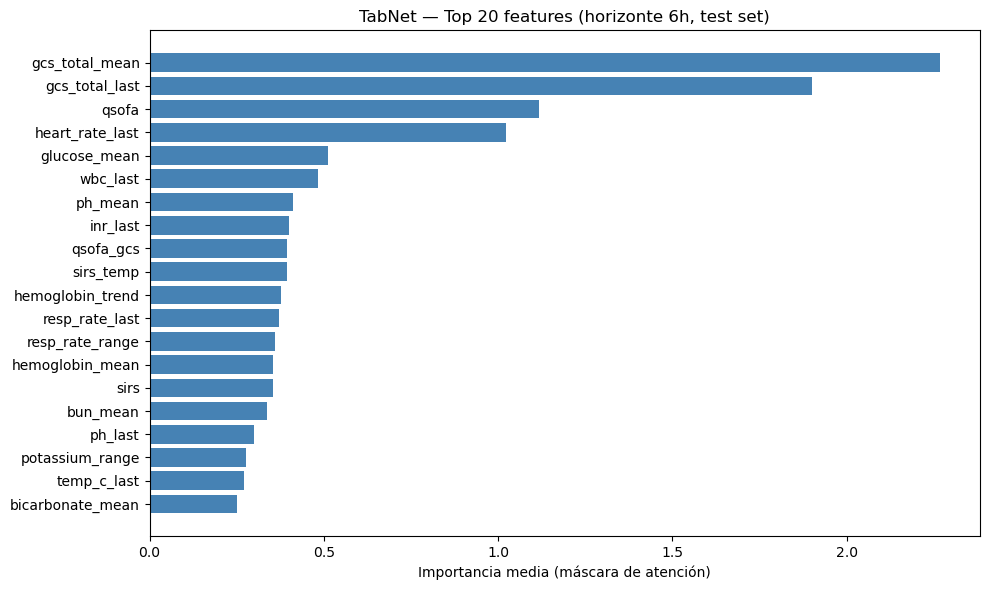

[19:46:50] Guardada: ../experiments/tabnet/tabnet_attention_6h.png


In [7]:
log("Calculando máscaras de atención (6h, test set) ...")

# explain() devuelve (agg_masks [n_samples, n_features], masks_dict {step: array})
agg_masks, masks = model_6h.explain(X_te6)

# Importancia global: media de la máscara agregada sobre todas las muestras
global_importance = agg_masks.mean(axis=0)
top_idx   = np.argsort(global_importance)[::-1][:20]
top_feats = [FEATURE_COLS[i] for i in top_idx]
top_vals  = global_importance[top_idx]

print("Top 20 features (atención TabNet media):")
for i, (feat, val) in enumerate(zip(top_feats, top_vals)):
    bar = '█' * int(val / top_vals[0] * 30)
    print(f"  {i+1:>2}. {feat:<32} {val:.4f}  {bar}")

# Figura
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_feats[::-1], top_vals[::-1], color="steelblue")
ax.set_xlabel("Importancia media (máscara de atención)")
ax.set_title("TabNet — Top 20 features (horizonte 6h, test set)")
fig.tight_layout()
fig.savefig(OUT_DIR / "tabnet_attention_6h.png", dpi=150, bbox_inches="tight")
plt.show()
log(f"Guardada: {OUT_DIR / 'tabnet_attention_6h.png'}")

## PASO 7 — Guardar modelos y métricas

In [8]:
import pickle

model_6h.save_model(str(OUT_DIR / "tabnet_6h"))
model_12h.save_model(str(OUT_DIR / "tabnet_12h"))

# Guardar imputer y scaler (necesarios para inferencia)
with open(OUT_DIR / "preprocessor_6h.pkl",  "wb") as f: pickle.dump((imp6,  sc6),  f)
with open(OUT_DIR / "preprocessor_12h.pkl", "wb") as f: pickle.dump((imp12, sc12), f)

results = {
    "6h":  {"val": r6_val,  "test": r6_test},
    "12h": {"val": r12_val, "test": r12_test},
    "n_features": len(FEATURE_COLS),
    "tabnet_params": {k: str(v) for k, v in TABNET_PARAMS.items()
                      if not callable(v)},
}
with open(OUT_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))
log("Completado — modelos en experiments/tabnet/")

Successfully saved model at ../experiments/tabnet/tabnet_6h.zip
Successfully saved model at ../experiments/tabnet/tabnet_12h.zip
{
  "6h": {
    "val": {
      "auroc": 0.7125,
      "auprc": 0.278,
      "sens_at_spec90": 0.3236
    },
    "test": {
      "auroc": 0.7655,
      "auprc": 0.3829,
      "sens_at_spec90": 0.4348
    }
  },
  "12h": {
    "val": {
      "auroc": 0.708,
      "auprc": 0.2966,
      "sens_at_spec90": 0.3452
    },
    "test": {
      "auroc": 0.7695,
      "auprc": 0.3768,
      "sens_at_spec90": 0.446
    }
  },
  "n_features": 99,
  "tabnet_params": {
    "n_d": "32",
    "n_a": "32",
    "n_steps": "5",
    "gamma": "1.3",
    "n_independent": "2",
    "n_shared": "2",
    "lambda_sparse": "0.001",
    "optimizer_params": "{'lr': 0.002, 'weight_decay': 1e-05}",
    "scheduler_params": "{'mode': 'max', 'patience': 5, 'factor': 0.5}",
    "mask_type": "sparsemax",
    "device_name": "cuda",
    "seed": "42",
    "verbose": "10"
  }
}
[19:46:50] Completado —